# Sprint 1 exploration — RQ6 & RQ7

**RQ6:** Which cropland, grazing areas and cattle populations experience the greatest historical flood exposure?

**RQ7:** Which areas combine high flood hazard with high exposure of population, livelihoods and critical infrastructure?

### Scope note (deliberately kept Sprint-1 level)
- Everything is aggregated to **admin2 (county)** level. This is a simplification — flooding, cropland, rangeland and cattle are all real spatial rasters at different resolutions (250m flood pixels, 500m crop/rangeland, ~1km cattle, 100m population), so county-level averages hide within-county detail. That's fine for now: the goal is *do patterns exist*, not exact numbers.
- No composite risk index, no weighting scheme — that's a Sprint 2 decision.
- Flood frequency here = number of distinct years a county had at least one flooded pixel. This mixes "recurring" and "unusual" flood types together; splitting those out is a natural Sprint 2 follow-up.

Run the cells top to bottom. Each section below is its own cell/tab so you can inspect intermediate outputs.


## 0. Imports

In [16]:
import glob
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask


## 1. Config — EDIT ME

Point these at your actual data folders, and optionally restrict `MY_COUNTIES`
to your subgroup's assigned region.


In [17]:
DATA_DIR = "C:/Users/thijn/OneDrive/TU Eindhoven/Data Science 2026-2027/Capstone Data Challenge JBG060/JBG060_ZHL_2026/raw_data"  # root folder where you keep all the raw files

ADMIN2_PATH = os.path.join(DATA_DIR, "Administrative boundaries", "ssd_admin2.geojson")

FLOOD_DIR_RECURRING = os.path.join(DATA_DIR, "flood_masks", "compact_recurring")
FLOOD_DIR_UNUSUAL = os.path.join(DATA_DIR, "flood_masks", "compact_unusual")

CROP_RASTER = os.path.join(DATA_DIR, "farmland", "asap_mask_crop_v04.tif")
RANGELAND_RASTER = os.path.join(DATA_DIR, "farmland", "asap_mask_rangeland_v04.tif")
CATTLE_RASTER = os.path.join(DATA_DIR, "farmland", "geonode__cattle_gha.tif")
POP_RASTER = os.path.join(DATA_DIR, "worldpop", "ssd_pop_2025_CN_100m_R2025A_v1.tif")

# Optional: restrict to the counties your subgroup is exploring.
# Leave as None to use all counties.
MY_COUNTIES = None  # e.g. ["Malakal", "Renk", "Pibor"]

OUTPUT_DIR = "outputs_sprint1"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 2. Load admin boundaries (counties)

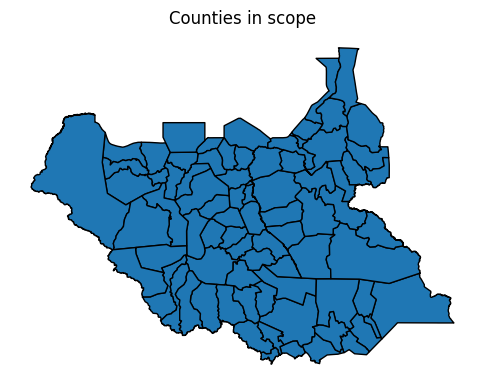

,adm2_name,adm2_name1,adm2_name2,adm2_name3,adm2_pcode,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,...,area_sqkm,version,lang,lang1,lang2,lang3,adm2_ref_name,center_lat,center_lon,geometry
0,Juba,None,None,None,SS0101,Central Equatoria,None,None,None,SS01,...,18366.514881,v03,en,None,None,None,Juba,4.713323,31.330985,"POLYGON ((32.12034 5.13695, 32.1199 5.1385, 32..."
1,Kajo-keji,None,None,None,SS0102,Central Equatoria,None,None,None,SS01,...,2516.104546,v03,en,None,None,None,Kajo-keji,3.909802,31.438481,"POLYGON ((31.69216 3.95909, 31.69206 3.95919, ..."
2,Lainya,None,None,None,SS0103,Central Equatoria,None,None,None,SS01,...,3498.916146,v03,en,None,None,None,Lainya,4.206289,30.809829,"POLYGON ((31.17471 4.37282, 31.17503 4.37347, ..."
3,Morobo,None,None,None,SS0104,Central Equatoria,None,None,None,SS01,...,1308.941909,v03,en,None,None,None,Morobo,3.718076,30.817847,"POLYGON ((31.04738 3.81817, 31.04738 3.82137, ..."
4,Terekeka,None,None,None,SS0105,Central Equatoria,None,None,None,SS01,...,10672.129966,v03,en,None,None,None,Terekeka,5.700817,31.428532,"POLYGON ((32.10548 5.49597, 32.10685 5.55038, ..."


In [18]:
admin2 = gpd.read_file(ADMIN2_PATH).to_crs("EPSG:4326")

if MY_COUNTIES:
    admin2 = admin2[admin2["adm2_name"].isin(MY_COUNTIES)].copy()

admin2 = admin2.reset_index(drop=True)
admin2.plot(edgecolor="black", figsize=(6, 6))
plt.title("Counties in scope")
plt.axis("off")
plt.show()

admin2.head()


## 3. Load flood mask points

Loads all recurring + unusual MODIS/VIIRS flood parquet files into one
GeoDataFrame of flood pixel-days. Adjust the glob patterns if you're only
using specific tiles/years for your region.


In [19]:
files = (
    glob.glob(os.path.join(FLOOD_DIR_RECURRING, "*.parquet"))
    + glob.glob(os.path.join(FLOOD_DIR_UNUSUAL, "*.parquet"))
)

if not files:
    raise FileNotFoundError(
        "No flood mask parquet files found — check FLOOD_DIR_RECURRING / "
        "FLOOD_DIR_UNUSUAL paths."
    )

flood = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
flood["date"] = pd.to_datetime(flood["date"])
flood["year"] = flood["date"].dt.year

flood_gdf = gpd.GeoDataFrame(
    flood,
    geometry=gpd.points_from_xy(flood["lon"], flood["lat"]),
    crs="EPSG:4326",
)

print(f"Loaded {len(flood_gdf):,} flood pixel-day records from {len(files)} files")
flood_gdf.head()


Loaded 95,255,114 flood pixel-day records from 104 files


,date,lat,lon,tile,cloud_frac,year,geometry
0,2000-03-02,2.155208,22.076042,h20v08,0.0,2000,POINT (22.07604 2.15521)
1,2000-03-02,2.128125,21.519793,h20v08,0.0,2000,POINT (21.51979 2.12812)
2,2000-03-02,2.086458,21.344791,h20v08,0.0,2000,POINT (21.34479 2.08646)
3,2000-03-02,2.076042,22.590626,h20v08,0.0,2000,POINT (22.59063 2.07604)
4,2000-03-02,2.073958,22.582293,h20v08,0.0,2000,POINT (22.58229 2.07396)


## 4. Flood frequency per county

Spatial-join flood pixel-days to counties, then count the number of
**distinct years** each county experienced at least one flooded pixel.
Simple and interpretable — good enough for a Sprint 1 first look.


In [20]:
joined = gpd.sjoin(
    flood_gdf, admin2[["adm2_name", "geometry"]], how="inner", predicate="within"
)

freq = (
    joined.groupby("adm2_name")["year"]
    .nunique()
    .reset_index(name="flood_frequency_years")
)

# raw pixel-day count -> rough severity proxy
counts = joined.groupby("adm2_name").size().reset_index(name="flood_pixel_days")

freq = freq.merge(counts, on="adm2_name", how="outer")

admin2 = admin2.merge(freq, on="adm2_name", how="left").fillna(
    {"flood_frequency_years": 0, "flood_pixel_days": 0}
)

admin2[["adm2_name", "flood_frequency_years", "flood_pixel_days"]].sort_values(
    "flood_frequency_years", ascending=False
).head(10)


,adm2_name,flood_frequency_years,flood_pixel_days
4,Terekeka,26.0,94901.0
14,Akobo,26.0,232384.0
8,Kapoeta East,26.0,697620.0
11,Lafon,26.0,152956.0
12,Magwi,26.0,3893.0
41,Leer,26.0,254707.0
25,Awerial,26.0,329042.0
23,Twic East,26.0,1556000.0
24,Uror,26.0,137640.0
21,Pibor,26.0,613919.0


## 5. Cropland %, rangeland %, cattle sum, population sum per county

No `rasterstats` dependency here — just `rasterio.mask.mask` (clip the raster
to one county polygon at a time) plus `numpy` to aggregate the pixels inside
each clip. Slower than `rasterstats` for many polygons, but only needs
`rasterio`/`numpy`, which you likely already have installed for the other
raster datasets in this project.

`zonal_reduce` reprojects the county polygons to match each raster's own CRS
first (the crop/rangeland/cattle/population rasters aren't guaranteed to all
share the same CRS as the admin boundaries), clips per polygon, and applies
`mean` or `sum` while ignoring nodata pixels.


In [21]:
def zonal_reduce(gdf, raster_path, col_name, how="mean"):
    """Add a column to gdf with the mean or sum of raster_path's pixel
    values inside each polygon. how: 'mean' or 'sum'."""
    reducer = np.nanmean if how == "mean" else np.nansum

    with rasterio.open(raster_path) as src:
        # match polygon CRS to the raster's CRS before clipping
        gdf_r = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        nodata = src.nodata

        values = []
        for geom in gdf_r.geometry:
            try:
                clipped, _ = mask(src, [geom], crop=True, nodata=nodata)
            except ValueError:
                # geometry doesn't overlap the raster extent at all
                values.append(0.0)
                continue

            band = clipped[0].astype("float64")
            if nodata is not None:
                band = np.where(band == nodata, np.nan, band)

            if np.all(np.isnan(band)):
                values.append(0.0)
            else:
                values.append(float(reducer(band)))

    gdf[col_name] = values
    return gdf


admin2 = zonal_reduce(admin2, CROP_RASTER, "crop_pct", how="mean")
admin2 = zonal_reduce(admin2, RANGELAND_RASTER, "rangeland_pct", how="mean")
admin2 = zonal_reduce(admin2, CATTLE_RASTER, "cattle_sum", how="sum")
admin2 = zonal_reduce(admin2, POP_RASTER, "pop_sum", how="sum")

admin2[["adm2_name", "crop_pct", "rangeland_pct", "cattle_sum", "pop_sum"]].head(10)


,adm2_name,crop_pct,rangeland_pct,cattle_sum,pop_sum
0,Juba,0.066982,44.409094,360601.765584,528189.548842
1,Kajo-keji,0.165448,30.909230,91808.318606,226798.574167
2,Lainya,0.171373,16.537760,63668.745223,113726.794643
3,Morobo,0.797368,16.103484,69227.841617,110556.665793
4,Terekeka,0.021411,31.230170,237603.710735,256708.672898
5,Yei,0.230209,17.406117,116147.543667,285331.314432
6,Budi,1.674513,28.236360,128606.946319,102088.271927
7,Ikotos,2.297297,29.237730,70411.285705,102388.962011
8,Kapoeta East,0.905775,35.739622,470100.267743,165894.372928
9,Kapoeta North,0.946457,48.439144,82947.960799,149557.710439


## 6. Save the merged county table

In [22]:
table_path = os.path.join(OUTPUT_DIR, "county_flood_exposure_table.csv")
admin2.drop(columns="geometry").to_csv(table_path, index=False)
print(f"Saved merged county table to {table_path}")


Saved merged county table to outputs_sprint1\county_flood_exposure_table.csv


## 7. RQ6 — flood frequency map

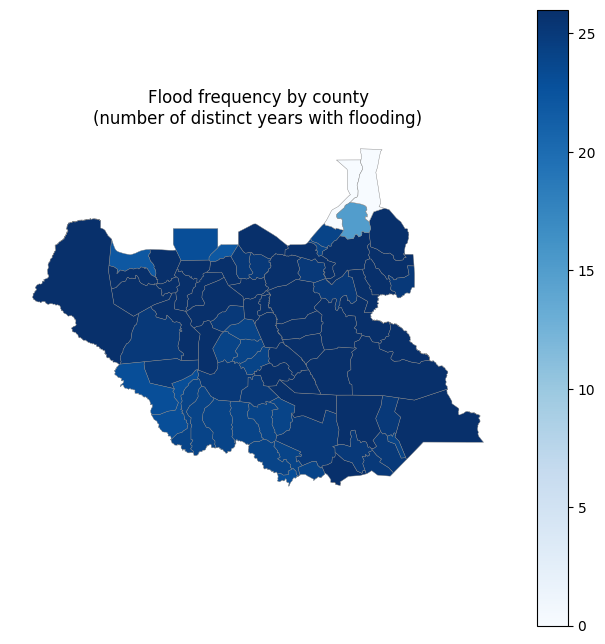

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))
admin2.plot(
    column="flood_frequency_years", cmap="Blues", legend=True,
    edgecolor="grey", linewidth=0.3, ax=ax,
)
ax.set_title("Flood frequency by county\n(number of distinct years with flooding)")
ax.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "rq6_flood_frequency_map.png"), dpi=150, bbox_inches="tight")
plt.show()


## 8. RQ6 — side-by-side exposure maps

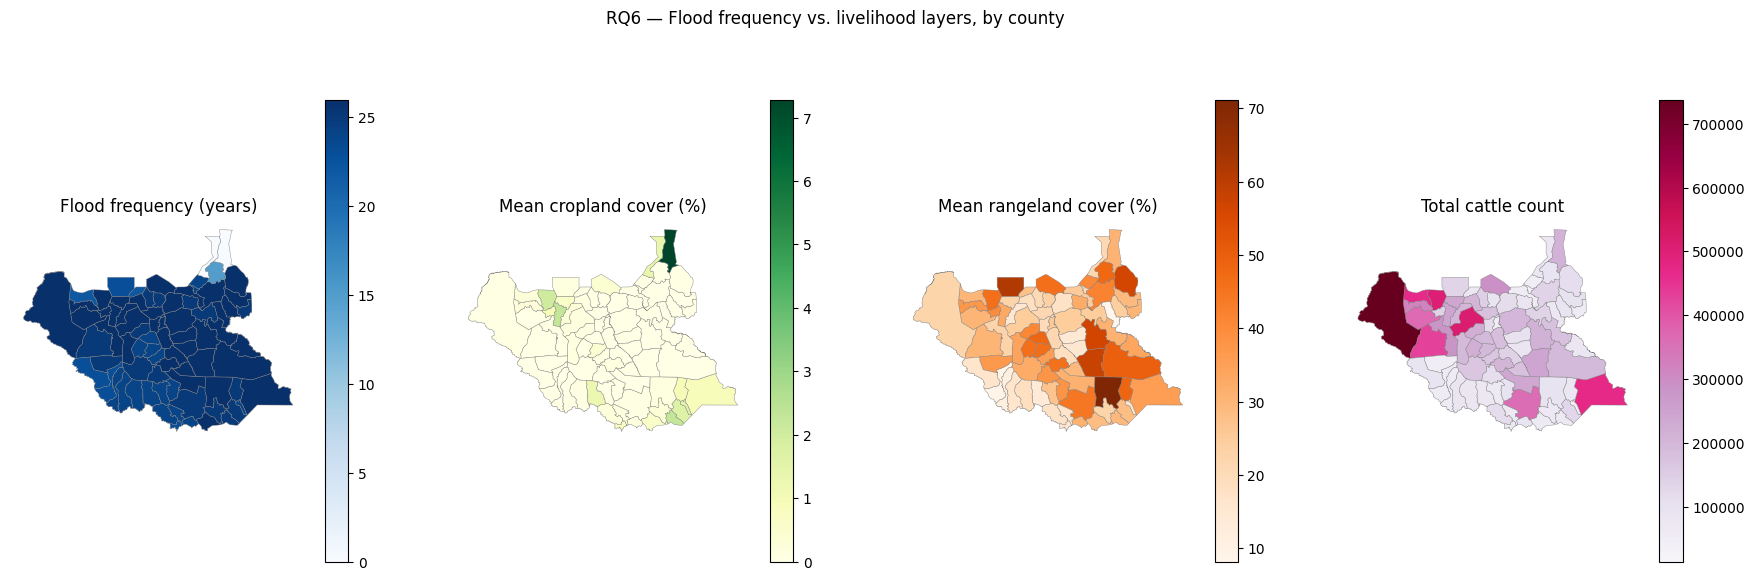

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

admin2.plot(column="flood_frequency_years", cmap="Blues", legend=True,
            edgecolor="grey", linewidth=0.3, ax=axes[0])
axes[0].set_title("Flood frequency (years)")

admin2.plot(column="crop_pct", cmap="YlGn", legend=True,
            edgecolor="grey", linewidth=0.3, ax=axes[1])
axes[1].set_title("Mean cropland cover (%)")

admin2.plot(column="rangeland_pct", cmap="Oranges", legend=True,
            edgecolor="grey", linewidth=0.3, ax=axes[2])
axes[2].set_title("Mean rangeland cover (%)")

admin2.plot(column="cattle_sum", cmap="PuRd", legend=True,
            edgecolor="grey", linewidth=0.3, ax=axes[3])
axes[3].set_title("Total cattle count")

for ax in axes:
    ax.axis("off")

fig.suptitle("RQ6 — Flood frequency vs. livelihood layers, by county", y=1.03)
plt.savefig(os.path.join(OUTPUT_DIR, "rq6_side_by_side_maps.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. RQ6 — bar chart: most flood-frequent counties' land cover

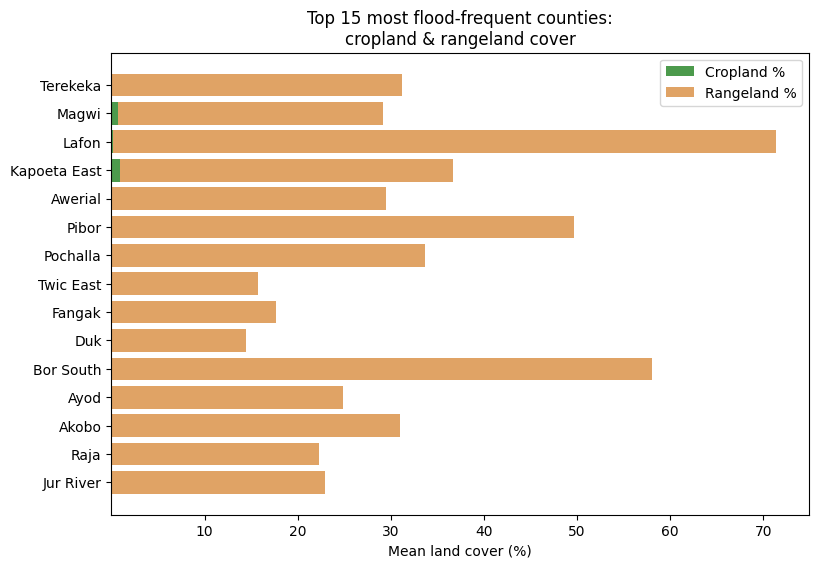

In [25]:
top_n = 15
df = admin2[admin2["flood_frequency_years"] > 0].copy()
df = df.sort_values("flood_frequency_years", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df["adm2_name"], df["crop_pct"], color="#4c9a4c", label="Cropland %")
ax.barh(df["adm2_name"], df["rangeland_pct"], left=df["crop_pct"],
        color="#d98c3f", label="Rangeland %", alpha=0.8)
ax.invert_yaxis()
ax.set_xlabel("Mean land cover (%)")
ax.set_title(f"Top {top_n} most flood-frequent counties:\ncropland & rangeland cover")
ax.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "rq6_exposure_bar_chart.png"), dpi=150, bbox_inches="tight")
plt.show()


## 10. RQ7 — hazard vs. exposure scatter

Rough first pass: flood frequency (hazard) vs. a single exposure variable.
No weighting or combined index yet — that's Sprint 2.


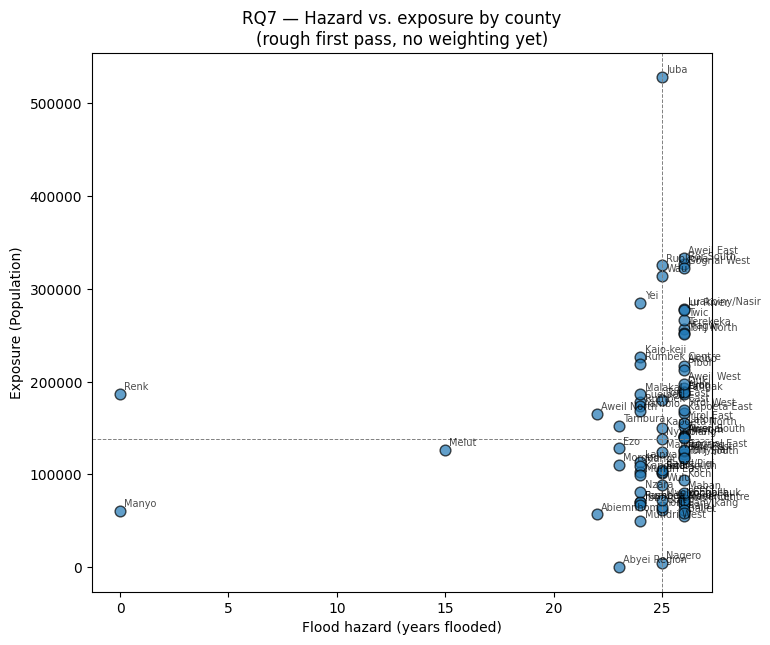

In [26]:
exposure_col = "pop_sum"
exposure_label = "Population"

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(admin2["flood_frequency_years"], admin2[exposure_col],
           s=60, alpha=0.7, edgecolor="k")

for _, row in admin2.iterrows():
    ax.annotate(row["adm2_name"],
                (row["flood_frequency_years"], row[exposure_col]),
                fontsize=7, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Flood hazard (years flooded)")
ax.set_ylabel(f"Exposure ({exposure_label})")
ax.set_title("RQ7 — Hazard vs. exposure by county\n(rough first pass, no weighting yet)")
ax.axhline(admin2[exposure_col].median(), color="grey", linestyle="--", linewidth=0.7)
ax.axvline(admin2["flood_frequency_years"].median(), color="grey", linestyle="--", linewidth=0.7)

plt.savefig(os.path.join(OUTPUT_DIR, "rq7_hazard_exposure_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()


## 11. RQ7 — priority highlight map

Flags counties above-median on *both* hazard and exposure — a rough,
unweighted "candidates for further investigation" map, not a final risk index.


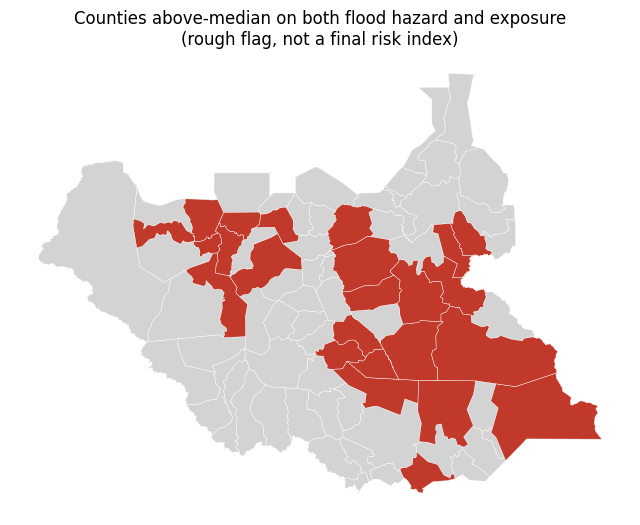

In [27]:
haz_med = admin2["flood_frequency_years"].median()
exp_med = admin2[exposure_col].median()
admin2["priority_flag"] = (
    (admin2["flood_frequency_years"] > haz_med) & (admin2[exposure_col] > exp_med)
)

fig, ax = plt.subplots(figsize=(8, 8))
admin2.plot(color="lightgrey", edgecolor="white", linewidth=0.3, ax=ax)
admin2[admin2["priority_flag"]].plot(color="#c0392b", edgecolor="white",
                                      linewidth=0.3, ax=ax)
ax.set_title("Counties above-median on both flood hazard and exposure\n(rough flag, not a final risk index)")
ax.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "rq7_priority_map.png"), dpi=150, bbox_inches="tight")
plt.show()


## 12. Summary table

In [28]:
admin2[["adm2_name", "flood_frequency_years", "crop_pct", "rangeland_pct",
         "cattle_sum", "pop_sum", "priority_flag"]].sort_values(
    "flood_frequency_years", ascending=False
).head(10)


,adm2_name,flood_frequency_years,crop_pct,rangeland_pct,cattle_sum,pop_sum,priority_flag
4,Terekeka,26.0,0.021411,31.230170,237603.710735,256708.672898,True
14,Akobo,26.0,0.000429,31.025371,175699.180720,216930.528499,True
8,Kapoeta East,26.0,0.905775,35.739622,470100.267743,165894.372928,True
11,Lafon,26.0,0.160410,71.186239,96294.679551,151927.868296,True
12,Magwi,26.0,0.648974,28.485976,63785.930633,252629.128806,True
41,Leer,26.0,0.010048,25.427273,50149.180499,77331.855700,False
25,Awerial,26.0,0.018962,29.505599,176328.241558,141373.642596,True
23,Twic East,26.0,0.000000,15.771032,88299.618111,122406.906421,False
24,Uror,26.0,0.003289,56.610761,217525.103478,188566.236339,True
21,Pibor,26.0,0.000571,49.657393,193875.538549,213105.500403,True


In [3]:
print("flood_gdf" in globals())

False
